# Planner - set_position demo

Minimal demonstration of the `Planner.set_position` method with asymmetric acceleration limits.
The planner shapes a step command into a smooth trapezoidal velocity profile.

In [1]:
import numpy
import matplotlib.pyplot as plt
from planner import Planner

## Parameters

In [2]:
dt = 1.0 / 250.0

# acceleration constraints
acc_fwd   = 3.0    # m/s² forward acceleration
dec_fwd   = 10.0    # m/s² deceleration (much faster)
acc_w_max = 1.0    # rad/s² angular acceleration (symmetric)

planner = Planner(acc_fwd, dec_fwd, acc_w_max, mpc_horizon=16, dt=dt)

## Generate step command sequence
Similar to the shaper notebook: step to +0.1 m at t=1 s, then to -0.1 m at t=2 s.

In [3]:
duration = 10.0
num_samples = int(duration / dt)

x_command = numpy.zeros(num_samples)
a_command = numpy.zeros(num_samples)

for n in range(num_samples):
    t = n * dt
    if t > 6.0:
        x_command[n] = 0.0
        a_command[n] = 0.0
    elif t > 2.0:
        x_command[n] = 1.0
        a_command[n] = 1.0
    else:
        x_command[n] = 0.0
        a_command[n] = 0.0

## Run planner in closed loop
Assume the position controller tracks the setpoint perfectly (ideal tracking).

In [4]:
# state: [x, v, theta, omega]
state = [0.0, 0.0, 0.0, 0.0]

x_shaped = numpy.zeros(num_samples)
a_shaped = numpy.zeros(num_samples)

for n in range(num_samples):
    x_new, a_new = planner.set_position(state, x_command[n], a_command[n])

    # ideal state update: controller tracks perfectly
    v_new = (x_new - state[0]) / dt
    w_new = (a_new - state[2]) / dt
    state = [x_new, v_new, a_new, w_new]

    x_shaped[n] = x_new
    a_shaped[n] = a_new

## Compute velocity, acceleration, jerk from position

In [5]:
v_shaped = numpy.gradient(x_shaped, dt)
a_shaped_acc = numpy.gradient(v_shaped, dt)
j_shaped = numpy.gradient(a_shaped_acc, dt)

w_shaped = numpy.gradient(a_shaped, dt)

## Plot results

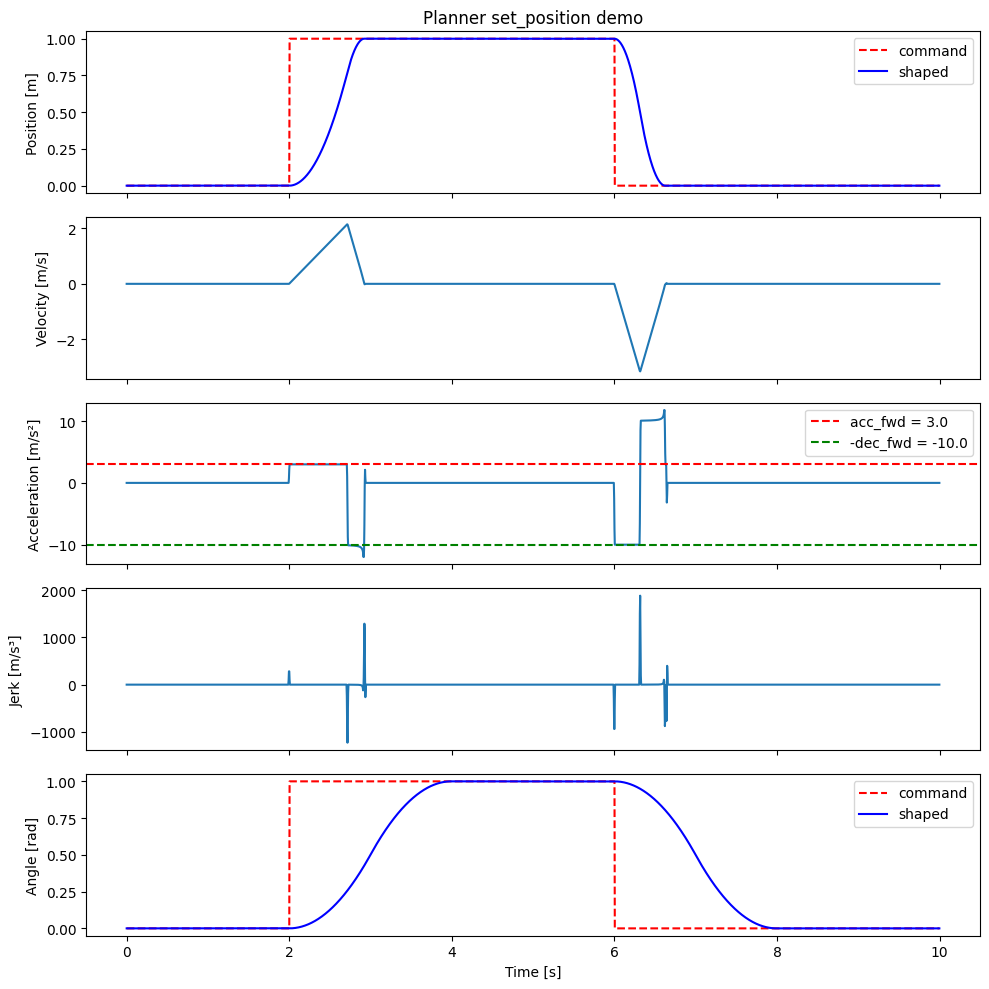

In [6]:
time_steps = dt * numpy.arange(num_samples)

fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)

axes[0].plot(time_steps, x_command, 'r--', label='command')
axes[0].plot(time_steps, x_shaped, 'b', label='shaped')
axes[0].set_ylabel('Position [m]')
axes[0].legend()
axes[0].set_title('Planner set_position demo')

axes[1].plot(time_steps, v_shaped)
axes[1].set_ylabel('Velocity [m/s]')

axes[2].plot(time_steps, a_shaped_acc)
axes[2].axhline( acc_fwd, color='r', ls='--', label=f'acc_fwd = {acc_fwd}')
axes[2].axhline(-dec_fwd, color='g', ls='--', label=f'-dec_fwd = {-dec_fwd}')
axes[2].set_ylabel('Acceleration [m/s²]')
axes[2].legend()

axes[3].plot(time_steps, j_shaped)
axes[3].set_ylabel('Jerk [m/s³]')

axes[4].plot(time_steps, a_command, 'r--', label='command')
axes[4].plot(time_steps, a_shaped, 'b', label='shaped')
axes[4].set_ylabel('Angle [rad]')
axes[4].set_xlabel('Time [s]')
axes[4].legend()

plt.tight_layout()
plt.show()